# Vectorización de Texto: Métodos Frecuentistas
## UNR · TUIA · Procesamiento de Lenguaje Natural — Unidad 2

Para que un modelo pueda trabajar con texto, primero hay que convertirlo en números.
En esta práctica exploramos los métodos clásicos con un dataset real de libros.

| Parte | Tema | Ejercicios |
|-------|------|-----------|
| 1 | Preparación del dataset | Ej 1, 2 |
| 2 | One-Hot Encoding | Ej 3 |
| 3 | Count Vectorizer | Ej 4 |
| 4 | N-grams | — (solo lectura) |
| 5 | TF-IDF | Ej 5 |
| 6 | Hash Vectorizer | — (solo lectura) |
| 7 | Comparación de métodos | Ej 6, 7 |
| 8 | Visualización con PCA | Ej 8 |

> **Texto**: sinopsis (`sinapsis`) · **Etiqueta**: subgénero · **Dataset**: Lectulandia


In [35]:
# ── Dependencias ─────────────────────────────────────────────────────────────
#!pip install scikit-learn numpy pandas matplotlib seaborn

import re, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse

from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, HashingVectorizer
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
np.random.seed(42)

print("Imports OK")


Imports OK


In [2]:
# ── Descarga del dataset ──────────────────────────────────────────────────────
import os, urllib.request

DATA_PATH = "data/lectulandia_books.csv"
GDRIVE_ID = "147g4SlXZtguJ7LZ1-9zxaHiYXlTApqru"

os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)

if not os.path.exists(DATA_PATH):
    print("Descargando lectulandia_books.csv desde Google Drive...")
    try:
        import gdown
        gdown.download(id=GDRIVE_ID, output=DATA_PATH, quiet=False)
    except ImportError:
        # Fallback sin gdown (funciona para archivos públicos sin confirmación)
        url = f"https://drive.google.com/uc?export=download&id={GDRIVE_ID}"
        urllib.request.urlretrieve(url, DATA_PATH)
    print(f"Dataset guardado en: {DATA_PATH}")
else:
    print(f"Dataset ya existe en: {DATA_PATH}")


Dataset ya existe en: data/lectulandia_books.csv


---
# Parte 1 – Preparación del Dataset

## El dataset: Lectulandia

Tenemos un CSV con ~476 libros. Cada fila tiene:

| Columna | Ejemplo |
|---------|---------|
| `titulo` | "El año del pensamiento mágico" |
| `autor` | "Joan Didion" |
| `sinapsis` | Texto libre de ~200 palabras |
| `generos` | "Biografía - Crónica - Literatura" |

El campo `generos` puede tener varios valores separados por ` - `. Vamos a usar el
**segundo género** como etiqueta de clase (es el más discriminativo).

## ¿Por qué balancear?

Los tres subgéneros más frecuentes tienen muy distinta cantidad de libros:
Crónica tiene ~169, Ensayo ~78 y Divulgación ~59.

Si dejamos ese desbalance, el modelo aprende a predecir siempre la clase mayoritaria
y parece bueno sin aprender nada útil. Por eso tomamos la misma cantidad de libros
de cada clase.

## Limpieza del texto

Antes de vectorizar, limpiamos cada sinopsis:

```python
import re

def limpiar_texto(texto):
    texto = texto.lower()                       # minúsculas
    texto = re.sub(r"[^\w\s]", " ", texto)    # sin puntuación
    texto = re.sub(r"\d+", " ", texto)         # sin números
    texto = re.sub(r"\s+", " ", texto).strip() # sin espacios dobles
    return texto
```


### Ejercicio 1 – Preparar el Dataset

In [3]:
import re

def limpiar_texto(texto):
    texto = texto.lower()                       # minúsculas
    texto = re.sub(r"[^\w\s]", " ", texto)    # sin puntuación
    texto = re.sub(r"\d+", " ", texto)         # sin números
    texto = re.sub(r"\s+", " ", texto).strip() # sin espacios dobles
    return texto

In [4]:
def preparar_dataset(path):
    """
    TODO:
    1. Cargar el CSV y eliminar filas con sinapsis o géneros vacíos
    2. Extraer el 2° género como etiqueta ('label')
    3. Quedarse con los top-3 géneros y balancear (random_state=42)
    4. Limpiar la sinopsis → columna 'sinapsis_clean'
       (minúsculas, sin puntuación, sin números)
    """
    pass

# df = preparar_dataset(DATA_PATH)

df = pd.read_csv(DATA_PATH)
# me quedo con las columnas titulo, autor, sinapsis y generos
df = df[['titulo', 'autor', 'sinapsis', 'generos']]
df.head()

,titulo,autor,sinapsis,generos
0,Tierra feroz,Jota Quijorna,La oscuridad de un alma herida es el hogar de ...,Intriga - Novela
1,Tehanu,Ursula K. Le Guin,"El mal medra, y la magia se ha pervertido. En ...",Fantástico - Novela
2,El niño del taxi,Sylvain Prudhomme,"Durante el funeral de su abuelo, Simon descubr...",Histórico - Novela
3,James Bond 007: El juego de rol,Gerard Christopher Klug,ATRÉVETE A VIVIR EN EL FASCINANTE MUNDO DE JAM...,Juegos - Manuales y cursos - Referencia
4,El retorno del cuervo,Alissa Brontë,"Tras varios años alejado del que fue su hogar,...",Histórico - Novela - Romántico


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62279 entries, 0 to 62278
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   titulo    62279 non-null  object
 1   autor     62278 non-null  object
 2   sinapsis  47830 non-null  object
 3   generos   62278 non-null  object
dtypes: object(4)
memory usage: 1.9+ MB


In [6]:
# eliminar filas con sinapsis o géneros vacíos
df = df.dropna(subset=['sinapsis', 'generos'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47830 entries, 0 to 61942
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   titulo    47830 non-null  object
 1   autor     47829 non-null  object
 2   sinapsis  47830 non-null  object
 3   generos   47830 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [7]:
# 2. Extraer el 2° género como etiqueta ('label')
# Crónica - Memorias
# Arqueología - Ciencias sociales - Divulgación - Historia
# Si no hay 2° género, me quedo con el 1° (Decisión propia)
# aplicar la funcion limpiar_texto al genero resultante
df['label'] = df['generos'].apply(lambda x: limpiar_texto(x.split('-')[1]) if len(x.split('-')) > 1 else limpiar_texto(x.split('-')[0]))
df.head()

,titulo,autor,sinapsis,generos,label
0,Tierra feroz,Jota Quijorna,La oscuridad de un alma herida es el hogar de ...,Intriga - Novela,novela
1,Tehanu,Ursula K. Le Guin,"El mal medra, y la magia se ha pervertido. En ...",Fantástico - Novela,novela
2,El niño del taxi,Sylvain Prudhomme,"Durante el funeral de su abuelo, Simon descubr...",Histórico - Novela,novela
3,James Bond 007: El juego de rol,Gerard Christopher Klug,ATRÉVETE A VIVIR EN EL FASCINANTE MUNDO DE JAM...,Juegos - Manuales y cursos - Referencia,manuales y cursos
4,El retorno del cuervo,Alissa Brontë,"Tras varios años alejado del que fue su hogar,...",Histórico - Novela - Romántico,novela


In [8]:
# Chequear si hay label vacías
print(df['label'].isna().sum())

0


In [9]:
df['label'].value_counts()

label
novela              16669
relato               2895
otros                2704
ensayo               2623
historia             2569
                    ...  
religión                1
recopilación            1
novela del oeste        1
aventuras               1
esoterismo              1
Name: count, Length: 113, dtype: int64

#### 3. Quedarse con los top-3 géneros y balancear (random_state=42)

In [10]:
# 3. Quedarse con los top-3 géneros y balancear (random_state=42)
top_3 = df['label'].value_counts().nlargest(3).index
df_top3 = df[df['label'].isin(top_3)]
df_balanced = df_top3.groupby('label').sample(n=df_top3['label'].value_counts().min(), random_state=42)
df_balanced['label'].value_counts()

label
novela    2704
otros     2704
relato    2704
Name: count, dtype: int64

In [11]:
# 4. Limpiar la sinopsis → columna 'sinapsis_clean' (minúsculas, sin puntuación, sin números)
df['sinapsis_clean'] = df['sinapsis'].apply(limpiar_texto)

df_balanced['sinapsis_clean'] = df_balanced['sinapsis'].apply(limpiar_texto)
df_balanced.head()

,titulo,autor,sinapsis,generos,label,sinapsis_clean
17589,El secreto de Toledo,Jaime García Simón,Una muerte en extrañas circunstancias en mitad...,Intriga - Novela,novela,una muerte en extrañas circunstancias en mitad...
39607,El Gran Vidrio,Mario Bellatin,El Gran Vidrio es una fiesta que se realiza an...,Drama - Novela,novela,el gran vidrio es una fiesta que se realiza an...
39659,Un viento de acero,Robert Margerit,La tercera entrega del monumental ciclo narrat...,Histórico - Novela,novela,la tercera entrega del monumental ciclo narrat...
27389,Sangre intocable,Maribel Medina,"¿Todas las vidas valen lo mismo? En Benarés, l...",Intriga - Novela,novela,todas las vidas valen lo mismo en benarés la c...
11335,Letras de ozono,Rober H. L. Cagiao,Tino Casal y Jason Romero son el director y ed...,Intriga - Novela - Policíaco,novela,tino casal y jason romero son el director y ed...


### Ejercicio 2 – Explorar el Corpus

In [12]:
def explorar_corpus(df):
    """
    TODO:
    1. Mostrar cuántos libros hay por género
    2. Graficar la longitud de sinopsis por género (boxplot)
    3. Mostrar las 10 palabras más frecuentes del corpus
       (excluir stopwords básicas como 'el', 'de', 'la', etc.)
    """
    pass

explorar_corpus(df)


In [13]:
# 1. Mostrar cuántos libros hay por género
df['label'].value_counts()

label
novela              16669
relato               2895
otros                2704
ensayo               2623
historia             2569
                    ...  
religión                1
recopilación            1
novela del oeste        1
aventuras               1
esoterismo              1
Name: count, Length: 113, dtype: int64

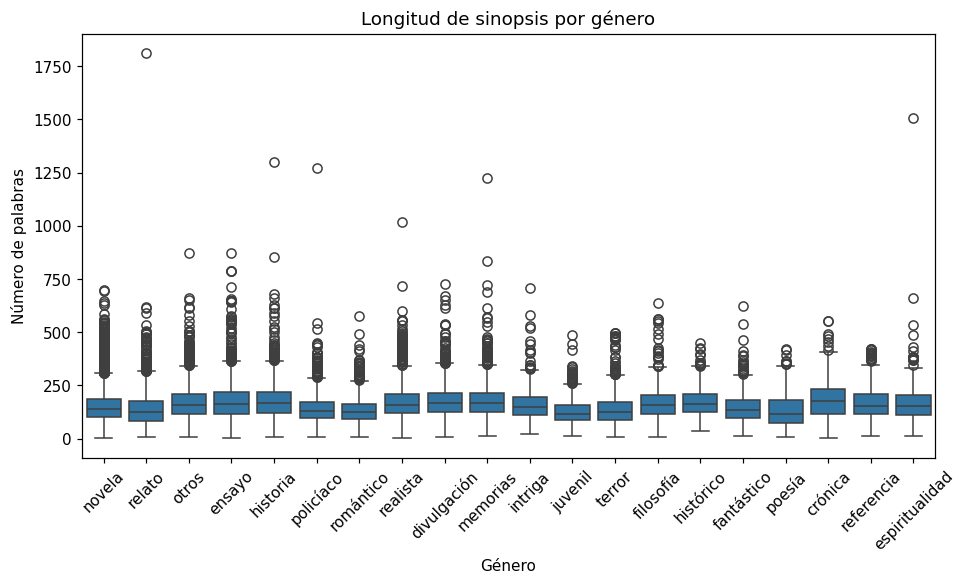

In [14]:
# 2. Graficar la longitud de sinopsis por género (boxplot) 
# ordenar por cantidad de libros por genero
# mostrar solo los 10 primeros géneros

order = df['label'].value_counts().index[:20]
df['sinapsis_length'] = df['sinapsis_clean'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 5))
sns.boxplot(x='label', y='sinapsis_length', data=df, order=order)
plt.title("Longitud de sinopsis por género")
# mostrar etiquetas legibles en el eje x a 45 grados
plt.xlabel("Género")
plt.ylabel("Número de palabras")
plt.xticks(rotation=45)
plt.show()

In [15]:
# 3. Mostrar las 10 palabras más frecuentes del corpus (excluir stopwords básicas como 'el', 'de', 'la', etc.)
stopwords = set([
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 'un', 
    'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le', 
    'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 'muy', 'sin', 
    'sobre', 'también', 'me', 'hasta', 'hay', 'donde', 'quien', 'desde', 'todo', 
    'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 
    'ante', 'ellos', 'e', 'esto', 'mí', 'antes', 'algunos', 'qué', 'unos', 'yo', 
    'otro', 'otras', 'otra', 'él', 'tanto', 'esa', 'estos', 'mucho', 'quienes', 
    'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 'estas', 'algunas', 'algo', 
    'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 'tu', 'tus', 'ellas', 'nosotras', 
    'vosotros', 'vosotras', 'os', 'mío', 'mía', 'míos', 'mías', 'tuyo', 'tuya', 
    'tuyos', 'tuyas', 'suyo', 'suya', 'suyos', 'suyas', 'nuestro', 'nuestra', 
    'nuestros', 'nuestras', 'vuestro', 'vuestra', 'vuestros', 'vuestras', 'es', 'ha','está','son'
])
all_words = ' '.join(df['sinapsis_clean']).split()
filtered_words = [word for word in all_words if word not in stopwords]
word_counts = Counter(filtered_words)
most_common = word_counts.most_common(10)
print("Las 10 palabras más frecuentes (excluyendo stopwords):")
for word, count in most_common:
    print(f"{word}: {count}")

Las 10 palabras más frecuentes (excluyendo stopwords):
vida: 22312
historia: 17156
años: 14708
mundo: 14569
novela: 13089
ser: 11767
libro: 11629
dos: 10484
vez: 9379
tiempo: 9048


---
# Parte 2 – One-Hot Encoding

## ¿Qué hace?

Cada documento se convierte en un vector de 0s y 1s. El vector tiene una posición
por cada palabra del vocabulario: `1` si la palabra aparece, `0` si no.

**Ejemplo** con tres documentos:

```
d1: "el gato come pescado"
d2: "el perro come carne"
d3: "el gato y el perro juegan"
```

| doc | carne | come | el | gato | juegan | perro | pescado | y |
|-----|:-----:|:----:|:--:|:----:|:------:|:-----:|:-------:|:-:|
| d1  |   0   |   1  |  1 |   1  |   0    |   0   |    1    | 0 |
| d2  |   1   |   1  |  1 |   0  |   0    |   1   |    0    | 0 |
| d3  |   0   |   0  |  1 |   1  |   1    |   1   |    0    | 1 |

En sklearn se obtiene con `CountVectorizer(binary=True)`.

## El problema: demasiados ceros

Si el vocabulario tiene 10 000 palabras y una sinopsis usa ~200, el vector tiene
9 800 ceros → **98% de ceros**. A esto lo llamamos **sparsidad**.

Esto es normal y manejable (sklearn usa formatos especiales que no guardan los ceros),
pero vale la pena entender cómo crece con el tamaño del vocabulario.


In [16]:
# ── Ejemplo interactivo: One-Hot Encoding ────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

corpus_demo = [
    "el gato come pescado",
    "el perro come carne",
    "el gato y el perro juegan",
]

cv_ohe = CountVectorizer(binary=True) # binary=True → solo presencia (1) o ausencia (0) de términos
X_ohe  = cv_ohe.fit_transform(corpus_demo)

print("=== One-Hot Encoding ===")
print(f"Shape: {X_ohe.shape}  (docs × términos)")
print(f"Sparsidad: {1 - X_ohe.nnz / (X_ohe.shape[0] * X_ohe.shape[1]):.1%}\n")

df_ohe = pd.DataFrame(
    X_ohe.toarray(),
    columns=cv_ohe.get_feature_names_out(),
    index=[f"d{i+1}" for i in range(len(corpus_demo))]
)
print(df_ohe.to_string())
print("\n→ Notar que 'el' en d3 aparece 2 veces, pero el valor es 1 (solo presencia)")


=== One-Hot Encoding ===
Shape: (3, 7)  (docs × términos)
Sparsidad: 42.9%

    carne  come  el  gato  juegan  perro  pescado
d1      0     1   1     1       0      0        1
d2      1     1   1     0       0      1        0
d3      0     0   1     1       1      1        0

→ Notar que 'el' en d3 aparece 2 veces, pero el valor es 1 (solo presencia)


### Ejercicio 3 – One-Hot Encoding

In [17]:
def analizar_one_hot(df):
    """
    TODO:
    1. Aplicar CountVectorizer(binary=True) sobre 'sinapsis_clean'
    2. Imprimir dimensiones de la matriz y porcentaje de ceros (sparsidad)
    3. Graficar cómo cambia la sparsidad al variar max_features
       en [500, 1000, 2000, 5000, None]
    """
    pass

analizar_one_hot(df)


In [18]:
#1. Aplicar CountVectorizer(binary=True) sobre 'sinapsis_clean'
cv_sinapsis = CountVectorizer(binary=True)
X_sinapsis = cv_sinapsis.fit_transform(df['sinapsis_clean'])


In [19]:
# 2. Imprimir dimensiones de la matriz y porcentaje de ceros (sparsidad)
print("=== One-Hot Encoding ===")
print(f"Shape: {X_sinapsis.shape}  (docs × términos)")
print(f"Sparsidad: {1 - X_sinapsis.nnz / (X_sinapsis.shape[0] * X_sinapsis.shape[1]):.1%}\n")
# Cantidad de terminos en el vocabulario
print(f"Cantidad de términos únicos: {len(cv_sinapsis.get_feature_names_out())}")


=== One-Hot Encoding ===
Shape: (47830, 174914)  (docs × términos)
Sparsidad: 99.9%

Cantidad de términos únicos: 174914


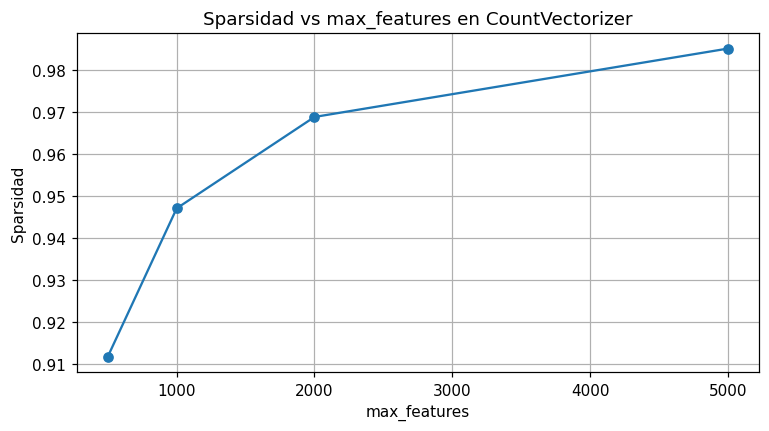

In [20]:
#3. Graficar cómo cambia la sparsidad al variar max_features
#       en [500, 1000, 2000, 5000, None]
# max_features: Le dice al programa que solo tenga en cuenta las "N" palabras más comunes de todos tus textos e ignore el resto.
max_features_list = [500, 1000, 2000, 5000, None]
sparsity_values = []
for max_features in max_features_list:
    cv = CountVectorizer(binary=True, max_features=max_features)
    X = cv.fit_transform(df['sinapsis_clean'])
    sparsity = 1 - X.nnz / (X.shape[0] * X.shape[1])
    sparsity_values.append(sparsity)
plt.figure(figsize=(8, 4))
plt.plot(max_features_list, sparsity_values, marker='o')
# plt.xscale('log')
plt.xlabel("max_features")
plt.ylabel("Sparsidad")
plt.title("Sparsidad vs max_features en CountVectorizer")
plt.grid(True)
plt.show()


---
# Parte 3 – Count Vectorizer

## ¿Qué hace?

A diferencia de One-Hot, Count Vectorizer guarda **cuántas veces** aparece cada
palabra (no solo si aparece o no).

```python
doc = ["el gato come come pescado pescado pescado"]

# One-Hot:  [1, 1, 1, 1]  → "pescado" y "come" valen igual que "el"
# Count:    [1, 2, 1, 3]  → "pescado" ×3 y "come" ×2 se capturan
```

## Parámetros útiles

| Parámetro | Para qué sirve | Ejemplo |
|-----------|---------------|---------|
| `max_features` | Limita el vocabulario a las N palabras más frecuentes | `max_features=5000` |
| `min_df` | Ignora palabras que aparecen en muy pocos documentos | `min_df=2` descarta hapax |
| `max_df` | Ignora palabras que aparecen en casi todos los documentos | `max_df=0.9` descarta stopwords |
| `binary` | Si `True`, equivale a One-Hot | `binary=True` |

**Regla práctica**: casi siempre conviene usar `min_df=2` para descartar palabras
únicas que no ayudan a generalizar.


In [21]:
# ── Ejemplo interactivo: Count Vectorizer ────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

corpus_demo = [
    "el gato come come pescado pescado pescado",
    "el perro come carne",
    "el gato y el perro juegan",
]

# Comparar binary=False vs binary=True
cv_count  = CountVectorizer(binary=False)
cv_binary = CountVectorizer(binary=True)

X_count  = cv_count.fit_transform(corpus_demo)
X_binary = cv_binary.fit_transform(corpus_demo)

idx = [f"d{i+1}" for i in range(len(corpus_demo))]

print("=== CountVectorizer (binary=False) — conteo de frecuencias ===")
df_c = pd.DataFrame(X_count.toarray(),
                    columns=cv_count.get_feature_names_out(), index=idx)
print(df_c.to_string())

print("\n=== CountVectorizer (binary=True) — solo presencia ===")
df_b = pd.DataFrame(X_binary.toarray(),
                    columns=cv_binary.get_feature_names_out(), index=idx)
print(df_b.to_string())

print("\n→ En d1: 'come'×2 y 'pescado'×3 se capturan con binary=False pero no con binary=True")

# Efecto de min_df y max_df
print("\n=== Efecto de min_df=2 (filtra palabras que aparecen en un solo doc) ===")
cv_mindf = CountVectorizer(min_df=2)
X_mindf  = cv_mindf.fit_transform(corpus_demo)
print("Vocabulario:", list(cv_mindf.get_feature_names_out()))


=== CountVectorizer (binary=False) — conteo de frecuencias ===
    carne  come  el  gato  juegan  perro  pescado
d1      0     2   1     1       0      0        3
d2      1     1   1     0       0      1        0
d3      0     0   2     1       1      1        0

=== CountVectorizer (binary=True) — solo presencia ===
    carne  come  el  gato  juegan  perro  pescado
d1      0     1   1     1       0      0        1
d2      1     1   1     0       0      1        0
d3      0     0   1     1       1      1        0

→ En d1: 'come'×2 y 'pescado'×3 se capturan con binary=False pero no con binary=True

=== Efecto de min_df=2 (filtra palabras que aparecen en un solo doc) ===
Vocabulario: ['come', 'el', 'gato', 'perro']


### Ejercicio 4 – Count Vectorizer: `min_df` y `max_df`

In [22]:
def explorar_count_vectorizer(df):
    """
    TODO:
    1. Probar min_df en [1, 2, 3, 5, 10] — registrar cuántas features quedan
    2. Probar max_df en [1.0, 0.9, 0.8, 0.7, 0.5] — registrar cuántas features quedan
    3. Graficar n_features vs cada parámetro
    """
    pass

explorar_count_vectorizer(df)


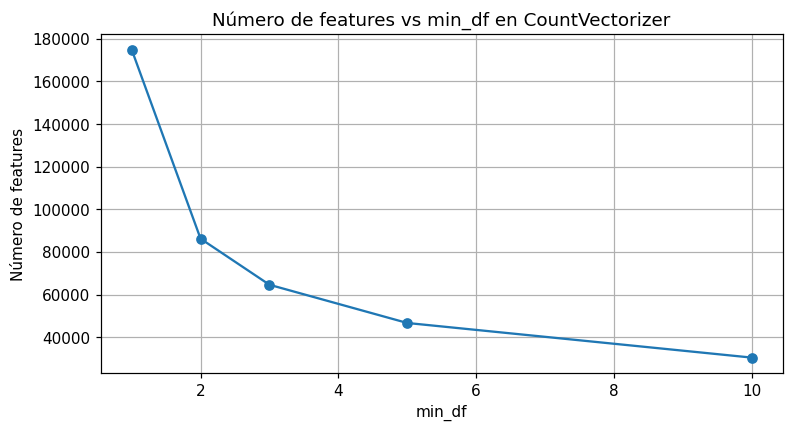

In [23]:
# 1. Probar min_df en [1, 2, 3, 5, 10] — registrar cuántas features quedan
min_df_values = [1, 2, 3, 5, 10]
features_count = []
for min_df in min_df_values:
    cv = CountVectorizer(min_df=min_df)
    cv.fit(df['sinapsis_clean'])
    features_count.append(len(cv.get_feature_names_out()))
plt.figure(figsize=(8, 4))
plt.plot(min_df_values, features_count, marker='o')
# plt.xscale('log')
plt.xlabel("min_df")
plt.ylabel("Número de features")
plt.title("Número de features vs min_df en CountVectorizer")
plt.grid(True)
plt.show()

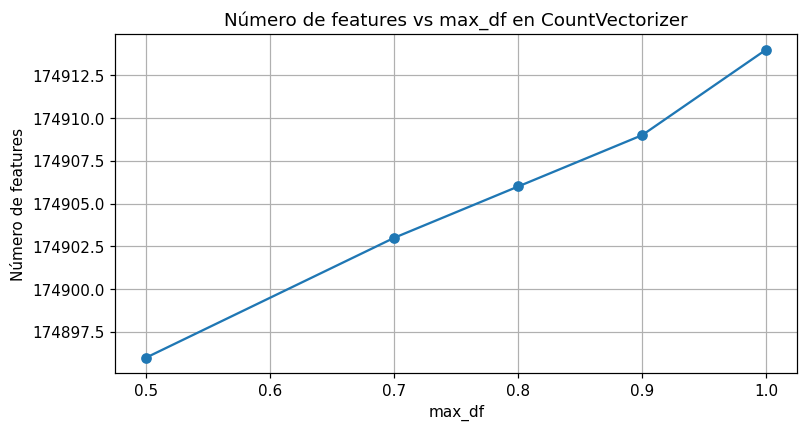

In [24]:
# 2. Probar max_df en [1.0, 0.9, 0.8, 0.7, 0.5] — registrar cuántas features quedan
max_df_values = [1.0, 0.9, 0.8, 0.7, 0.5]
features_count = []
for max_df in max_df_values:
    cv = CountVectorizer(max_df=max_df)
    cv.fit(df['sinapsis_clean'])
    features_count.append(len(cv.get_feature_names_out()))
plt.figure(figsize=(8, 4))
plt.plot(max_df_values, features_count, marker='o')
plt.xlabel("max_df")
plt.ylabel("Número de features")
plt.title("Número de features vs max_df en CountVectorizer")
plt.grid(True)
plt.show()

Observacion: El parametro min_df tiene mas impacto en la cantidad de terminos del vocabulario que el paremetro max_df.
Con lo cual que podemos concluir que en la sinapsis hay mas palabras raras que comunes.

---
# Parte 4 – N-grams

> Esta sección es **solo lectura**: entendé el concepto y ejecutá el ejemplo.
> Los n-grams los vas a usar en el Ejercicio 6 (benchmark).

## ¿Qué son?

Un **n-gram** es una secuencia de n palabras consecutivas.

| Tipo | Ejemplo sobre "primera guerra mundial" |
|------|----------------------------------------|
| Unigram (1) | "primera" · "guerra" · "mundial" |
| Bigram (2) | "primera guerra" · "guerra mundial" |
| Trigram (3) | "primera guerra mundial" |

## ¿Para qué sirven?

Los unigramas pierden el contexto. "no me gustó" tratado palabra a palabra puede
confundirse con "me gustó" porque comparten "me" y "gustó".

El bigrama "no me" o "no gustó" captura esa negación.

En sklearn se controla con `ngram_range=(min_n, max_n)`:

```python
# Solo palabras sueltas
CountVectorizer(ngram_range=(1, 1))

# Palabras sueltas + pares de palabras
CountVectorizer(ngram_range=(1, 2))

# Solo pares
CountVectorizer(ngram_range=(2, 2))
```

> Para clasificación de texto, `ngram_range=(1, 2)` suele mejorar los resultados
> respecto a usar solo unigramas, sin agregar demasiada complejidad.


In [25]:
# ── Ejemplo interactivo: N-grams ─────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer

corpus_demo = [
    "la primera guerra mundial fue terrible",
    "la segunda guerra mundial también fue terrible",
    "el libro sobre la guerra es excelente",
]

configs = {
    "(1,1) — solo unigrams":   (1, 1),
    "(1,2) — uni + bigrams":   (1, 2),
    "(2,2) — solo bigrams":    (2, 2),
    "(1,3) — uni+bi+trigrams": (1, 3),
}

for nombre, rango in configs.items():
    cv  = CountVectorizer(ngram_range=rango, min_df=1)
    X   = cv.fit_transform(corpus_demo)
    print(f"\n=== {nombre} ===")
    print(f"  n_features = {X.shape[1]}")
    print(f"  Vocabulario: {list(cv.get_feature_names_out())}")

print("\n→ Notar cómo 'primera guerra' y 'guerra mundial' son features en (1,2)")
print("→ 'primera guerra mundial' solo aparece como feature en (1,3)")



=== (1,1) — solo unigrams ===
  n_features = 13
  Vocabulario: ['el', 'es', 'excelente', 'fue', 'guerra', 'la', 'libro', 'mundial', 'primera', 'segunda', 'sobre', 'también', 'terrible']

=== (1,2) — uni + bigrams ===
  n_features = 28
  Vocabulario: ['el', 'el libro', 'es', 'es excelente', 'excelente', 'fue', 'fue terrible', 'guerra', 'guerra es', 'guerra mundial', 'la', 'la guerra', 'la primera', 'la segunda', 'libro', 'libro sobre', 'mundial', 'mundial fue', 'mundial también', 'primera', 'primera guerra', 'segunda', 'segunda guerra', 'sobre', 'sobre la', 'también', 'también fue', 'terrible']

=== (2,2) — solo bigrams ===
  n_features = 15
  Vocabulario: ['el libro', 'es excelente', 'fue terrible', 'guerra es', 'guerra mundial', 'la guerra', 'la primera', 'la segunda', 'libro sobre', 'mundial fue', 'mundial también', 'primera guerra', 'segunda guerra', 'sobre la', 'también fue']

=== (1,3) — uni+bi+trigrams ===
  n_features = 42
  Vocabulario: ['el', 'el libro', 'el libro sobre', 'es

---
# Parte 5 – TF-IDF

## El problema con Count Vectorizer

Si usamos solo frecuencias, palabras como "el", "de", "es" tienen conteos altísimos
en todos los documentos. No ayudan a distinguir géneros.

**TF-IDF** combina dos ideas:

- **TF** *(Term Frequency)*: qué tan frecuente es la palabra **en este documento**
- **IDF** *(Inverse Document Frequency)*: penaliza las palabras que aparecen
  en **todos** los documentos (poco útiles para distinguir)

Una palabra frecuente solo en algunos documentos → TF-IDF alto → útil para clasificar.  
Una palabra frecuente en todos los documentos → IDF bajo → peso bajo.

## Ejemplo

```
Corpus de 3 docs. La palabra "el" aparece en todos → IDF bajo → peso bajo.
La palabra "crónica" solo en 1 doc → IDF alto → peso alto.
```

## Parámetros importantes

| Parámetro | Qué hace |
|-----------|---------|
| `sublinear_tf=True` | Usa `log(1 + frecuencia)` en lugar de la frecuencia directa. Evita que documentos largos dominen por repetición. |
| `smooth_idf=True` | Evita errores matemáticos si un término aparece en todos los docs. Conviene dejarlo en `True`. |
| `use_idf=False` | Desactiva el IDF, quedando solo TF normalizado. |

> **Recomendación para empezar**: `TfidfVectorizer(sublinear_tf=True, min_df=2)` es
> un buen punto de partida para clasificación de texto.


In [26]:
# ── Ejemplo interactivo: TF-IDF ──────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

corpus_demo = [
    "el libro es bueno el libro es muy bueno",   # "libro" repetido
    "el libro tiene algunos errores graves",
    "el ensayo es brillante original y único",    # palabras únicas
]

tfidf = TfidfVectorizer()
X     = tfidf.fit_transform(corpus_demo)
feat  = tfidf.get_feature_names_out()

df_tfidf = pd.DataFrame(X.toarray().round(3),
                        columns=feat,
                        index=[f"d{i+1}" for i in range(len(corpus_demo))])
print("=== TF-IDF (smooth_idf=True, sublinear_tf=False) ===")
print(df_tfidf.to_string())

# Mostrar IDF de cada término
idf_series = pd.Series(tfidf.idf_, index=feat).sort_values()
print("\n=== IDF por término (menor = más común en el corpus) ===")
print(idf_series.round(3).to_string())
print("\n→ 'el' y 'es' tienen IDF bajo (aparecen en todos los docs)")
print("→ 'brillante', 'único', 'original' tienen IDF alto (aparecen en 1 solo doc)")

# Comparar sublinear_tf=False vs True
print("\n=== Efecto de sublinear_tf ===")
doc_largo  = ["guerra " * 50 + "economía inflación recesión"]
doc_corto  = ["guerra economía inflación recesión"]

for corpus_ex, label in [(doc_largo, "largo (guerra×50)"), (doc_corto, "corto (guerra×1)")]:
    for sublin, nombre in [(False, "sublinear=False"), (True, "sublinear=True")]:
        v = TfidfVectorizer(sublinear_tf=sublin)
        X_ex = v.fit_transform(corpus_ex)
        idx_guerra = list(v.get_feature_names_out()).index("guerra")
        print(f"  {label} | {nombre}: TF-IDF('guerra') = {X_ex[0, idx_guerra]:.4f}")


=== TF-IDF (smooth_idf=True, sublinear_tf=False) ===
    algunos  brillante  bueno     el  ensayo  errores     es  graves  libro    muy  original  tiene  único
d1    0.000      0.000  0.602  0.356   0.000    0.000  0.458   0.000  0.458  0.301     0.000  0.000  0.000
d2    0.451      0.000  0.000  0.266   0.000    0.451  0.000   0.451  0.343  0.000     0.000  0.451  0.000
d3    0.000      0.451  0.000  0.266   0.451    0.000  0.343   0.000  0.000  0.000     0.451  0.000  0.451

=== IDF por término (menor = más común en el corpus) ===
el           1.000
es           1.288
libro        1.288
brillante    1.693
bueno        1.693
ensayo       1.693
errores      1.693
algunos      1.693
graves       1.693
muy          1.693
original     1.693
tiene        1.693
único        1.693

→ 'el' y 'es' tienen IDF bajo (aparecen en todos los docs)
→ 'brillante', 'único', 'original' tienen IDF alto (aparecen en 1 solo doc)

=== Efecto de sublinear_tf ===
  largo (guerra×50) | sublinear=False: TF-IDF(

### Ejercicio 5 – TF-IDF: Palabras por Género

In [27]:
def palabras_por_genero(df):
    """
    TODO:
    1. Vectorizar con TfidfVectorizer(sublinear_tf=True, max_features=5000, min_df=2)
    2. Calcular el TF-IDF promedio por género. -> De los vectores obtenidos por cada genero, calcular el centroide 
    o vector promedio (sumo los vectores y luego divido)
    3. Graficar los 10 términos con mayor puntaje para cada género -> A partir del vector centroide obtener 
    los 10 libros mas cercanos al mismo por genero
    """
    pass

palabras_por_genero(df)


In [28]:
# 1. Vectorizar con TfidfVectorizer(sublinear_tf=True, max_features=5000, min_df=2)
tfidf_genero = TfidfVectorizer(sublinear_tf=True, max_features=5000, min_df=2)

# Obtengo las sinopsis limpias para el genero relato
df_relato = df[df['label'] == 'relato']
sinopsis_relato = df_relato['sinapsis_clean']
X_relato = tfidf_genero.fit_transform(sinopsis_relato)
features_relato = tfidf_genero.get_feature_names_out()

In [29]:
# Dimensiones y sparsidad de X_relato
print("=== TF-IDF para género 'relato' ===")
print(f"Shape: {X_relato.shape}  (docs × términos)")
print(f"Sparsidad: {1 - X_relato.nnz / (X_relato.shape[0] * X_relato.shape[1]):.1%}\n")
print(f"Cantidad de términos únicos: {len(features_relato)}")

=== TF-IDF para género 'relato' ===
Shape: (2895, 5000)  (docs × términos)
Sparsidad: 98.6%

Cantidad de términos únicos: 5000


In [30]:
# 2. Calcular el TF-IDF promedio por género. -> De los vectores obtenidos por cada genero, calcular el centroide 
#    o vector promedio (sumo los vectores y luego divido)

# tomo X_relato como ejemplo, pero se haría lo mismo para cada genero
tfidf_relato_centroide = X_relato.mean(axis=0)  # vector promedio (centroide) para el género 'relato'
# Convertir a ndarray para evitar errores con np.matrix en sklearn
tfidf_relato_centroide = np.asarray(tfidf_relato_centroide)

# A partir del vector centroide obtener los 10 libros mas cercanos al mismo por genero
distances = cosine_similarity(tfidf_relato_centroide, X_relato)
closest_books_indices = distances.argsort()[0][-10:]
closest_books = df_relato.iloc[closest_books_indices]
print("Los 10 libros más cercanos al centroide del género 'relato' son:")
print(closest_books[['titulo', 'autor']])


Los 10 libros más cercanos al centroide del género 'relato' son:
                             titulo                  autor
47326                       Cuentos       José Lezama Lima
6482          Los libros de cuentos           Willa Cather
11216         Ocho escenas de Tokio            Osamu Dazai
43260               Noche en Opwijk             Alan Pauls
6172                 La casa grande  Álvaro Cepeda Samudio
47178      Si me necesitas, llámame         Raymond Carver
32500              Intangibles S.A.        Brian W. Aldiss
41055                Prometeo & Cía          Eduardo Wilde
16327            La gente no existe          Laura Ferrero
1121   La desaparición de Hollywood     René Avilés Fabila


---
# Parte 6 – Hash Vectorizer

> Esta sección es **solo lectura**: entendé el concepto y ejecutá el ejemplo.

## ¿Cuándo Count y TF-IDF no alcanzan?

Ambos métodos necesitan construir un **vocabulario** antes de vectorizar.
Con millones de documentos o datos en tiempo real, esto puede ser un problema.

## La solución: el Hashing Trick

En vez de guardar `{"guerra": 42, "economía": 1337, ...}`, aplicamos una función
**hash** directamente a cada palabra para obtener su índice:

```python
indice = hash("guerra") % n_features   # siempre da el mismo número
```

No hay vocabulario que construir ni guardar.

```python
from sklearn.feature_extraction.text import HashingVectorizer

hv = HashingVectorizer(n_features=2**18, norm="l2")

# No necesita fit — transform directo
X = hv.transform(["el gato come pescado", "el perro come carne"])
```

## ¿Cuándo usarlo?

- Corpus muy grande que no cabe en memoria
- Datos en tiempo real (streaming)
- Cuando van a aparecer palabras nuevas en producción

## Parámetro clave: `n_features`

Define el tamaño fijo del vector. Con `2**18` ≈ 260 000 posiciones, las colisiones
(dos palabras distintas con el mismo índice) suelen ser despreciables.


In [31]:
# ── Ejemplo interactivo: Hash Vectorizer ─────────────────────────────────────
from sklearn.feature_extraction.text import HashingVectorizer, CountVectorizer
import numpy as np

corpus_demo = [
    "el gato come pescado",
    "el perro come carne",
    "el gato y el perro juegan",
]

print("=== HashingVectorizer (n_features=2^5=32) ===")
hv = HashingVectorizer(n_features=2**5, norm="l2", alternate_sign=True)
X_hash = hv.transform(corpus_demo)   # ¡No requiere fit!
print(f"Shape:     {X_hash.shape}")
print(f"NNZ total: {X_hash.nnz}")
print(f"NNZ/doc:   {X_hash.nnz / len(corpus_demo):.1f}")

print("\n→ No hay vocabulario almacenado (get_feature_names_out no existe)")
print(f"→ El mismo vectorizador sirve para cualquier texto nuevo sin reentrenar")

# Comparar dimensionalidad con CountVectorizer
cv = CountVectorizer()
X_cv = cv.fit_transform(corpus_demo)
print(f"\nCountVectorizer:  shape = {X_cv.shape}  (vocab = {len(cv.vocabulary_)} términos)")
print(f"HashVectorizer:   shape = {X_hash.shape}  (n_features fijo = 32)")

# Demostrar que no necesita fit: texto completamente nuevo
nuevo_texto = ["zorzal cantó entre los ceibos del litoral"]
X_nuevo = hv.transform(nuevo_texto)  # funciona sin reentrenar
print(f"\nTexto nuevo sin reentrenar: shape = {X_nuevo.shape}")

# Mostrar el problema de alternate_sign con MultinomialNB
print("\n=== alternate_sign y compatibilidad con Naive Bayes ===")
hv_pos = HashingVectorizer(n_features=2**10, norm=None, alternate_sign=False)
hv_alt = HashingVectorizer(n_features=2**10, norm=None, alternate_sign=True)
X_pos  = hv_pos.transform(corpus_demo)
X_alt  = hv_alt.transform(corpus_demo)
print(f"alternate_sign=False → valores negativos: {(X_pos.data < 0).sum()} (cero → OK para MultinomialNB)")
print(f"alternate_sign=True  → valores negativos: {(X_alt.data < 0).sum()} (algunos negativos → NO usar con MultinomialNB)")


=== HashingVectorizer (n_features=2^5=32) ===
Shape:     (3, 32)
NNZ total: 12
NNZ/doc:   4.0

→ No hay vocabulario almacenado (get_feature_names_out no existe)
→ El mismo vectorizador sirve para cualquier texto nuevo sin reentrenar

CountVectorizer:  shape = (3, 7)  (vocab = 7 términos)
HashVectorizer:   shape = (3, 32)  (n_features fijo = 32)

Texto nuevo sin reentrenar: shape = (1, 32)

=== alternate_sign y compatibilidad con Naive Bayes ===
alternate_sign=False → valores negativos: 0 (cero → OK para MultinomialNB)
alternate_sign=True  → valores negativos: 11 (algunos negativos → NO usar con MultinomialNB)


---
# Parte 7 – Comparación de Todos los Métodos

Hasta ahora aprendimos cada vectorizador por separado. Ahora los comparamos
con el mismo clasificador y la misma evaluación para ver cuál funciona mejor.

## Representaciones a comparar

| ID | Método | Configuración |
|----|--------|--------------|
| A | One-Hot | `binary=True, max_features=5000` |
| B | Count | `max_features=5000, min_df=2` |
| C | TF-IDF base | `max_features=5000, min_df=2` |
| D | TF-IDF sublinear | `sublinear_tf=True, max_features=5000` |
| E | TF-IDF bigramas | `ngram_range=(1,2), sublinear_tf=True` |

Clasificador: **Logistic Regression** con 5-fold cross-validation.


### Ejercicio 6 – Comparar Vectorizadores

In [32]:
def comparar_vectorizadores(df):
    """
    TODO:
    1. Crear los 5 vectorizadores:
       - One-Hot  (CountVectorizer binary=True, max_features=5000)
       - Count    (CountVectorizer max_features=5000, min_df=2)
       - TF-IDF base    (max_features=5000, min_df=2)
       - TF-IDF sublin  (sublinear_tf=True, max_features=5000, min_df=2)
       - TF-IDF bigrams (ngram_range=(1,2), sublinear_tf=True, max_features=8000)
    2. Evaluar cada uno con LogisticRegression (accuracy, cv=5)
    3. Mostrar tabla y gráfico de barras ordenado de mejor a peor
    """
    pass

comparar_vectorizadores(df)


In [ ]:
# creo variable para guardar los resultados de los modelos
resultados_modelos = pd.DataFrame()
# columnas modelo, clase, precision, recall, f1-score, support
# crear funcion que agregue los resultados del classification report al dataframe resultados_modelos
# si el resultado ya existe para ese modelo y clase, actualizarlo, sino agregar una nueva fila
def agregar_resultados_modelo(modelo_nombre, y_true, y_pred):
    global resultados_modelos
    report = classification_report(y_true, y_pred, output_dict=True)
    rows = []
    for clase, metrics in report.items():
        if clase not in ['accuracy', 'macro avg', 'weighted avg']:
            row = {
                'Modelo': modelo_nombre,
                'Clase': clase,
                'Precision': metrics.get('precision', None),
                'Recall': metrics.get('recall', None),
                'F1-Score': metrics.get('f1-score', None),
                'Support': metrics.get('support', None)
            }
            rows.append(row)
    if rows:
        # Agregar o actualizar los resultados en el DataFrame
        for row in rows:
            existing_index = resultados_modelos[
                (resultados_modelos['Modelo'] == modelo_nombre) &
                (resultados_modelos['Clase'] == row['Clase'])
            ].index
            if not existing_index.empty:
                # Actualizar fila existente
                idx = existing_index[0]
                resultados_modelos.at[idx, 'Precision'] = row['Precision']
                resultados_modelos.at[idx, 'Recall'] = row['Recall']
                resultados_modelos.at[idx, 'F1-Score'] = row['F1-Score']
                resultados_modelos.at[idx, 'Support'] = row['Support']
            else:
                # Agregar nueva fila
                resultados_modelos = pd.concat([resultados_modelos, pd.DataFrame([row])], ignore_index=True)        
    return

#### One-Hot max_features=5000

In [ ]:
# One-Hot  (CountVectorizer binary=True, max_features=5000)
# trabajo sobre df_balanced para tener un dataset balanceado
#2. Evaluar cada uno con LogisticRegression (accuracy, cv=5)

cv_ohe = CountVectorizer(binary=True, max_features=5000)
X_ohe = cv_ohe.fit_transform(df_balanced['sinapsis_clean'])
y_ohe = df_balanced['label']
model_ohe = LogisticRegression(max_iter=1000)
# split 80/20 (stratify=y)
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(X_ohe, y_ohe, test_size=0.2, random_state=42, stratify=y_ohe)
model_ohe.fit(X_train_ohe, y_train_ohe)
accuracy_ohe = model_ohe.score(X_test_ohe, y_test_ohe)
print(f"One-Hot Accuracy: {accuracy_ohe:.4f}")

y_pred_s = model_ohe.predict(X_test_ohe)

print("Resultados One-Hot\n")
print("\n---")
print("Classification Report:\n", classification_report(y_test_ohe, y_pred_s))
print("Balanced accuracy: ", round(balanced_accuracy_score(y_test_ohe, y_pred_s),2))

# agregar resultados del modelo sin balanceo
agregar_resultados_modelo('One-Hot', y_test_ohe, y_pred_s)

One-Hot Accuracy: 0.6402
Resultados con regresión logística sin balanceo


---
Classification Report:
               precision    recall  f1-score   support

      novela       0.64      0.64      0.64       541
       otros       0.56      0.59      0.58       541
      relato       0.72      0.69      0.71       541

    accuracy                           0.64      1623
   macro avg       0.64      0.64      0.64      1623
weighted avg       0.64      0.64      0.64      1623

Balanced accuracy:  0.64


#### CountVectorizer max_features=5000, min_df=2

In [39]:
# Repetir prueba con - Count    (CountVectorizer max_features=5000, min_df=2)
cv_count = CountVectorizer(max_features=5000, min_df=2)
X_count = cv_count.fit_transform(df_balanced['sinapsis_clean'])
y_count = df_balanced['label']
model_count = LogisticRegression(max_iter=1000)
X_train_count, X_test_count, y_train_count, y_test_count = train_test_split(X_count, y_count, test_size=0.2, random_state=42, stratify=y_count)
model_count.fit(X_train_count, y_train_count)
accuracy_count = model_count.score(X_test_count, y_test_count)
print(f"Count Accuracy: {accuracy_count:.4f}")  

y_pred_count = model_count.predict(X_test_count)

print("Resultados Count\n")
print("\n---")
print("Classification Report:\n", classification_report(y_test_count, y_pred_count))
print("Balanced accuracy: ", round(balanced_accuracy_score(y_test_count, y_pred_count),2))

# agregar resultados del modelo sin balanceo
agregar_resultados_modelo('Count', y_test_count, y_pred_count)

Count Accuracy: 0.6365
Resultados Count


---
Classification Report:
               precision    recall  f1-score   support

      novela       0.64      0.63      0.64       541
       otros       0.57      0.58      0.58       541
      relato       0.70      0.69      0.70       541

    accuracy                           0.64      1623
   macro avg       0.64      0.64      0.64      1623
weighted avg       0.64      0.64      0.64      1623

Balanced accuracy:  0.64


#### TF-IDF base (max_features=5000, min_df=2)

In [44]:
# Repetir prueba con - TF-IDF base    (max_features=5000, min_df=2)
tfidf_base = TfidfVectorizer(max_features=5000, min_df=2)
X_tfidf_base = tfidf_base.fit_transform(df_balanced['sinapsis_clean'])
y_tfidf_base = df_balanced['label']
model_tfidf_base = LogisticRegression(max_iter=1000)
X_train_tfidf_base, X_test_tfidf_base, y_train_tfidf_base, y_test_tfidf_base = train_test_split(X_tfidf_base, y_tfidf_base, test_size=0.2, random_state=42, stratify=y_tfidf_base)
model_tfidf_base.fit(X_train_tfidf_base, y_train_tfidf_base)
accuracy_tfidf_base = model_tfidf_base.score(X_test_tfidf_base, y_test_tfidf_base)
print(f"TF-IDF base Accuracy: {accuracy_tfidf_base:.4f}")

y_pred_tfidf_base = model_tfidf_base.predict(X_test_tfidf_base)

print("Resultados TF-IDF base\n")
print("\n---")
print("Classification Report:\n", classification_report(y_test_tfidf_base, y_pred_tfidf_base))
print("Balanced accuracy: ", round(balanced_accuracy_score(y_test_tfidf_base, y_pred_tfidf_base),2))

# agregar resultados del modelo sin balanceo
agregar_resultados_modelo('TF-IDF base', y_test_tfidf_base, y_pred_tfidf_base)

TF-IDF base Accuracy: 0.6956
Resultados TF-IDF base


---
Classification Report:
               precision    recall  f1-score   support

      novela       0.69      0.71      0.70       541
       otros       0.63      0.67      0.65       541
      relato       0.78      0.71      0.74       541

    accuracy                           0.70      1623
   macro avg       0.70      0.70      0.70      1623
weighted avg       0.70      0.70      0.70      1623

Balanced accuracy:  0.7


#### TF-IDF sublin  (sublinear_tf=True, max_features=5000, min_df=2)

In [52]:
# Repetir prueba con - TF-IDF sublin  (sublinear_tf=True, max_features=5000, min_df=2)
tfidf_sublin = TfidfVectorizer(sublinear_tf=True, max_features=5000, min_df=2)
X_tfidf_sublin = tfidf_sublin.fit_transform(df_balanced['sinapsis_clean'])
y_tfidf_sublin = df_balanced['label']
model_tfidf_sublin = LogisticRegression(max_iter=1000)
X_train_tfidf_sublin, X_test_tfidf_sublin, y_train_tfidf_sublin, y_test_tfidf_sublin = train_test_split(X_tfidf_sublin, y_tfidf_sublin, test_size=0.2, random_state=42, stratify=y_tfidf_sublin)
model_tfidf_sublin.fit(X_train_tfidf_sublin, y_train_tfidf_sublin)
accuracy_tfidf_sublin = model_tfidf_sublin.score(X_test_tfidf_sublin, y_test_tfidf_sublin)
print(f"TF-IDF sublin Accuracy: {accuracy_tfidf_sublin:.4f}")

y_pred_tfidf_sublin = model_tfidf_sublin.predict(X_test_tfidf_sublin)

print("Resultados TF-IDF sublin\n")
print("\n---")
print("Classification Report:\n", classification_report(y_test_tfidf_sublin, y_pred_tfidf_sublin))
print("Balanced accuracy: ", round(balanced_accuracy_score(y_test_tfidf_sublin, y_pred_tfidf_sublin),2))

# agregar resultados del modelo sin balanceo
agregar_resultados_modelo('TF-IDF sublin', y_test_tfidf_sublin, y_pred_tfidf_sublin)

TF-IDF sublin Accuracy: 0.6962
Resultados TF-IDF sublin


---
Classification Report:
               precision    recall  f1-score   support

      novela       0.69      0.72      0.71       541
       otros       0.62      0.67      0.64       541
      relato       0.79      0.70      0.74       541

    accuracy                           0.70      1623
   macro avg       0.70      0.70      0.70      1623
weighted avg       0.70      0.70      0.70      1623

Balanced accuracy:  0.7


#### TF-IDF bigrams (ngram_range=(1,2), sublinear_tf=True, max_features=8000)

In [48]:
# Repetir prueba con - TF-IDF bigrams (ngram_range=(1,2), sublinear_tf=True, max_features=8000)
tfidf_bigrams = TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True, max_features=8000)
X_tfidf_bigrams = tfidf_bigrams.fit_transform(df_balanced['sinapsis_clean'])
y_tfidf_bigrams = df_balanced['label']
model_tfidf_bigrams = LogisticRegression(max_iter=1000)
X_train_tfidf_bigrams, X_test_tfidf_bigrams, y_train_tfidf_bigrams, y_test_tfidf_bigrams = train_test_split(X_tfidf_bigrams, y_tfidf_bigrams, test_size=0.2, random_state=42, stratify=y_tfidf_bigrams)
model_tfidf_bigrams.fit(X_train_tfidf_bigrams, y_train_tfidf_bigrams)
accuracy_tfidf_bigrams = model_tfidf_bigrams.score(X_test_tfidf_bigrams, y_test_tfidf_bigrams)
print(f"TF-IDF bigrams Accuracy: {accuracy_tfidf_bigrams:.4f}")

y_pred_tfidf_bigrams = model_tfidf_bigrams.predict(X_test_tfidf_bigrams)

print("Resultados TF-IDF bigrams\n")
print("\n---")
print("Classification Report:\n", classification_report(y_test_tfidf_bigrams, y_pred_tfidf_bigrams))
print("Balanced accuracy: ", round(balanced_accuracy_score(y_test_tfidf_bigrams, y_pred_tfidf_bigrams),2))

# agregar resultados del modelo sin balanceo
agregar_resultados_modelo('TF-IDF bigrams', y_test_tfidf_bigrams, y_pred_tfidf_bigrams)

TF-IDF bigrams Accuracy: 0.6784
Resultados TF-IDF bigrams


---
Classification Report:
               precision    recall  f1-score   support

      novela       0.65      0.71      0.68       541
       otros       0.61      0.63      0.62       541
      relato       0.79      0.69      0.74       541

    accuracy                           0.68      1623
   macro avg       0.68      0.68      0.68      1623
weighted avg       0.68      0.68      0.68      1623

Balanced accuracy:  0.68


### Comparación de modelos

In [53]:
#ordenar el dataframe resultados_modelos por f1-score descendente
resultados_modelos = resultados_modelos.sort_values(by='F1-Score', ascending=False)
resultados_modelos

,Modelo,Clase,Precision,Recall,F1-Score,Support
0,TF-IDF base,relato,0.780488,0.709797,0.743466,541.0
14,TF-IDF sublin,relato,0.791232,0.700555,0.743137,541.0
1,TF-IDF bigrams,relato,0.791139,0.693161,0.738916,541.0
12,TF-IDF sublin,novela,0.693950,0.720887,0.707162,541.0
2,One-Hot,relato,0.720617,0.691312,0.705660,541.0
3,Count,relato,0.703565,0.693161,0.698324,541.0
4,TF-IDF base,novela,0.687050,0.706100,0.696445,541.0
5,TF-IDF bigrams,novela,0.653584,0.707948,0.679681,541.0
6,TF-IDF base,otros,0.631304,0.670980,0.650538,541.0
13,TF-IDF sublin,otros,0.620275,0.667283,0.642921,541.0


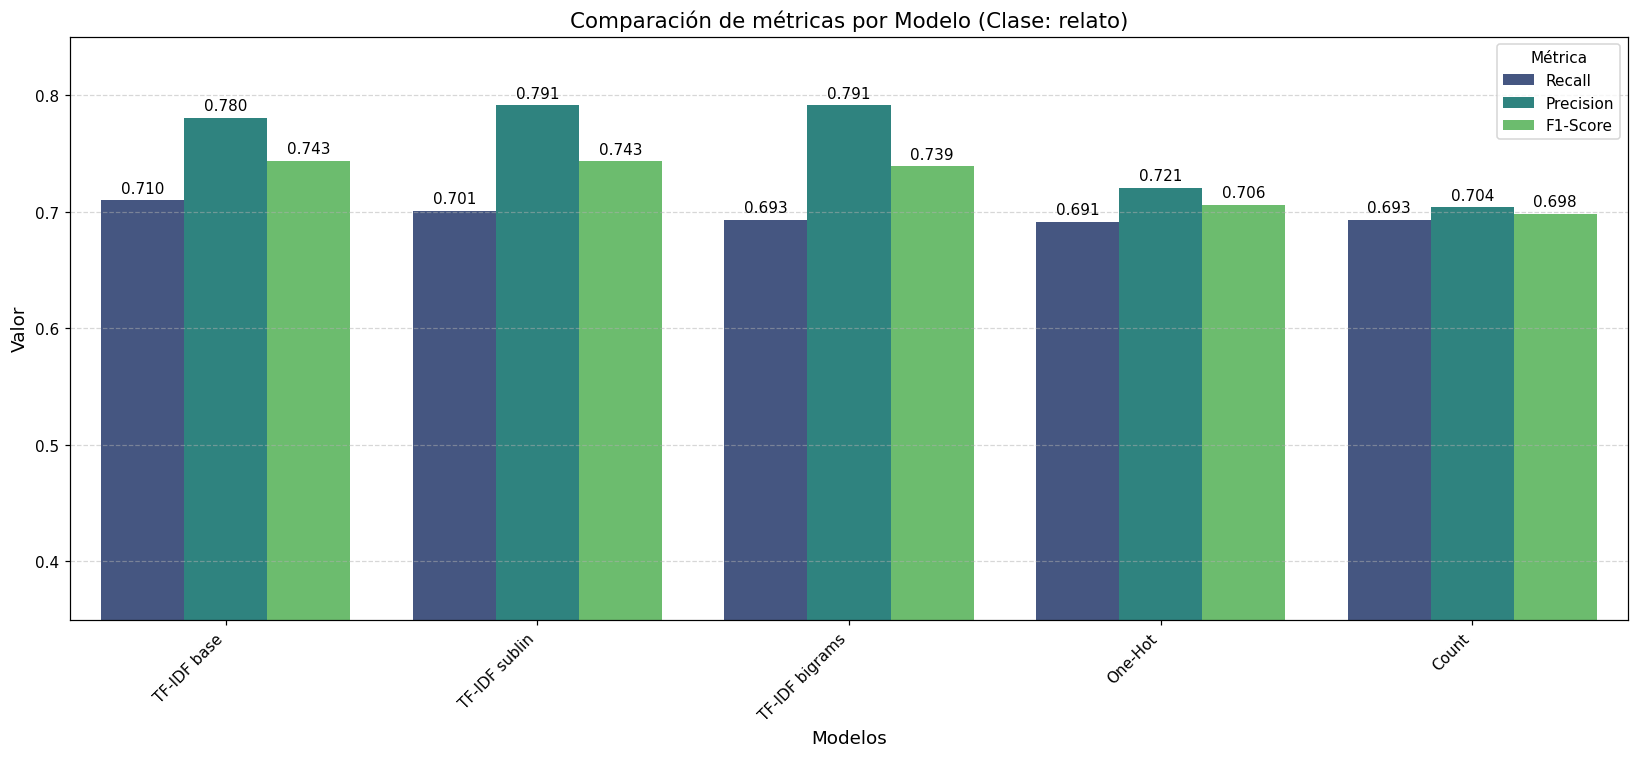

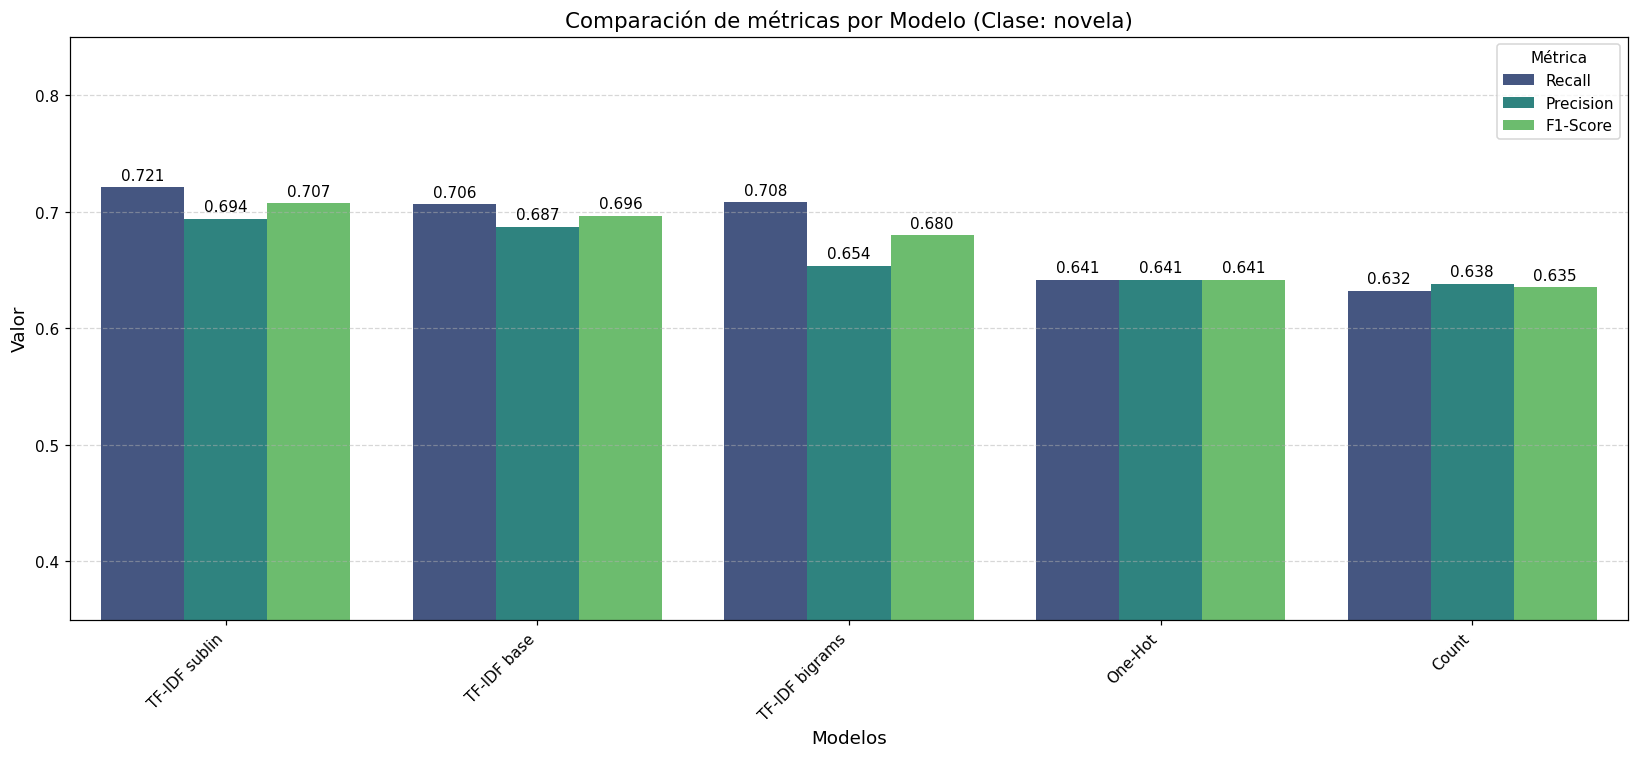

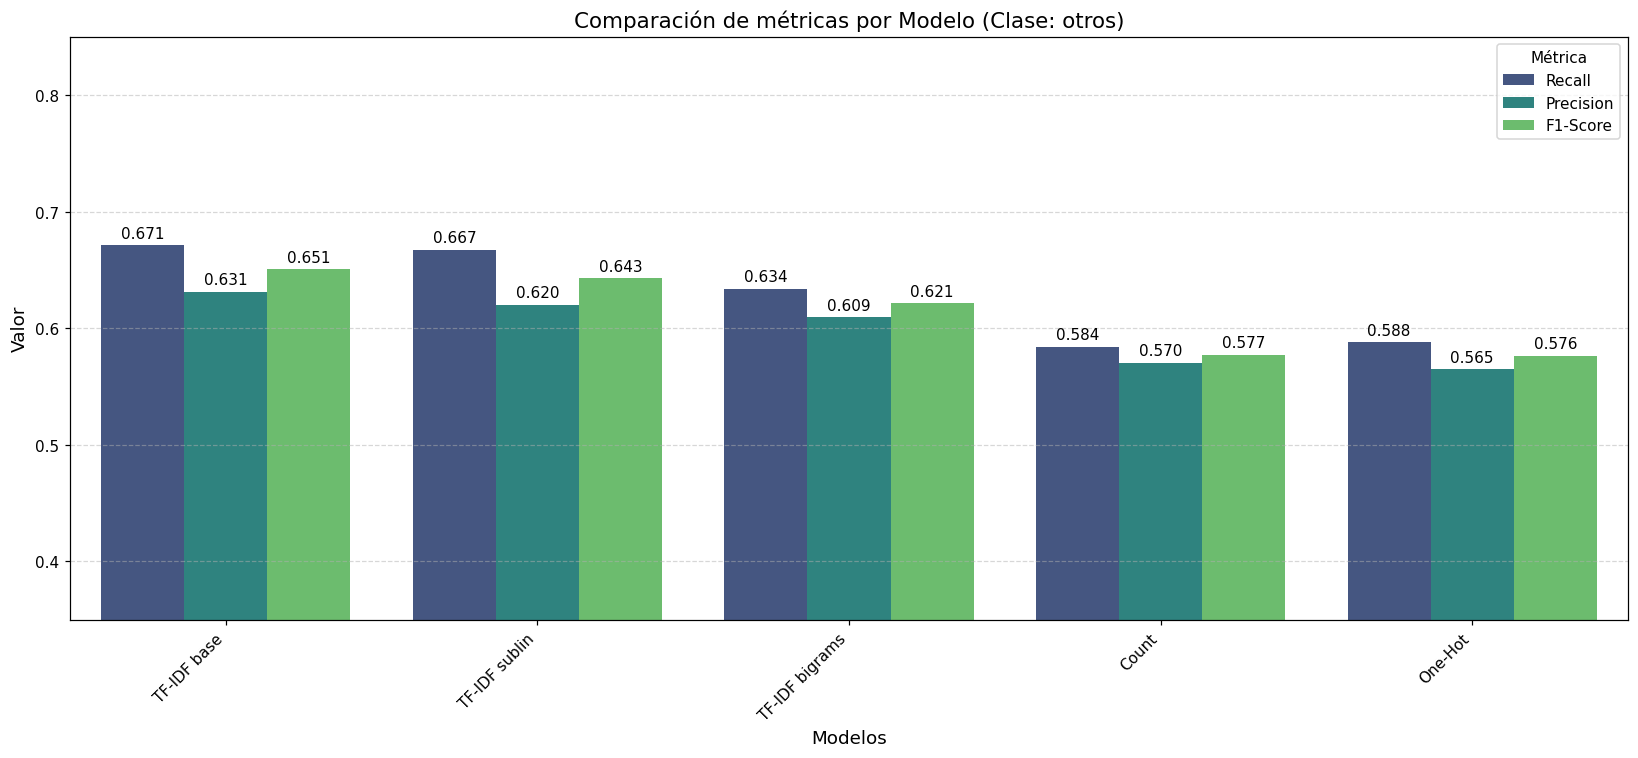

In [62]:
# Funcion para graficar los resultados de los modelos por clase (recall, precision, f1-score)

def graficar_resultados_modelos(clase):
    df_clase = resultados_modelos[resultados_modelos['Clase'] == clase].copy()
    df_melted = df_clase.melt(
        id_vars='Modelo', 
        value_vars=['Recall', 'Precision', 'F1-Score'], 
        var_name='Métrica', 
        value_name='Valor'
    )
    plt.figure(figsize=(15, 7))
    ax = sns.barplot(
        data=df_melted, 
        x='Modelo', 
        y='Valor', 
        hue='Métrica', 
        palette='viridis'
    )
    plt.title(f'Comparación de métricas por Modelo (Clase: {clase})', fontsize=14)
    plt.xlabel('Modelos', fontsize=12)
    plt.ylabel('Valor', fontsize=12)
    plt.ylim(0.35, 0.85) 
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Métrica', loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)
    plt.tight_layout()
    plt.show()

# Graficar resultados para cada clase
for clase in resultados_modelos['Clase'].unique():
    graficar_resultados_modelos(clase)

### Ejercicio 7 – Evaluar el Mejor Modelo

In [25]:
def evaluar_mejor_modelo(df):
    """
    TODO:
    1. Usar TF-IDF bigramas + LogisticRegression, split 80/20 (stratify=y)
    2. Mostrar la matriz de confusión normalizada
    3. Mostrar el classification report
    """
    pass

evaluar_mejor_modelo(df)


---
# Parte 8 – Visualización con PCA

Después del benchmark, es útil ver visualmente si los géneros se separan en el
espacio de representación. Usamos **TruncatedSVD** para reducir miles de dimensiones
a solo 2, y hacemos un scatter plot.

```python
from sklearn.decomposition import TruncatedSVD

svd  = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_sparse)   # pasa de (n_docs, n_features) a (n_docs, 2)
```

Si los puntos de cada género forman grupos separados, la representación es más útil.

> Los primeros 2 componentes suelen capturar solo el 10–15% de la varianza total.
> Que los puntos se superpongan no significa que el método sea malo — la separación
> puede existir en otras dimensiones que no podemos ver en 2D.


### Ejercicio 8 – Visualización 2D con PCA

In [26]:
def visualizar_en_2d(df):
    """
    TODO:
    1. Vectorizar con TF-IDF base y TF-IDF bigramas
    2. Reducir a 2 dimensiones con TruncatedSVD(n_components=2)
    3. Hacer un scatter plot coloreado por género para cada representación
    """
    pass

visualizar_en_2d(df)


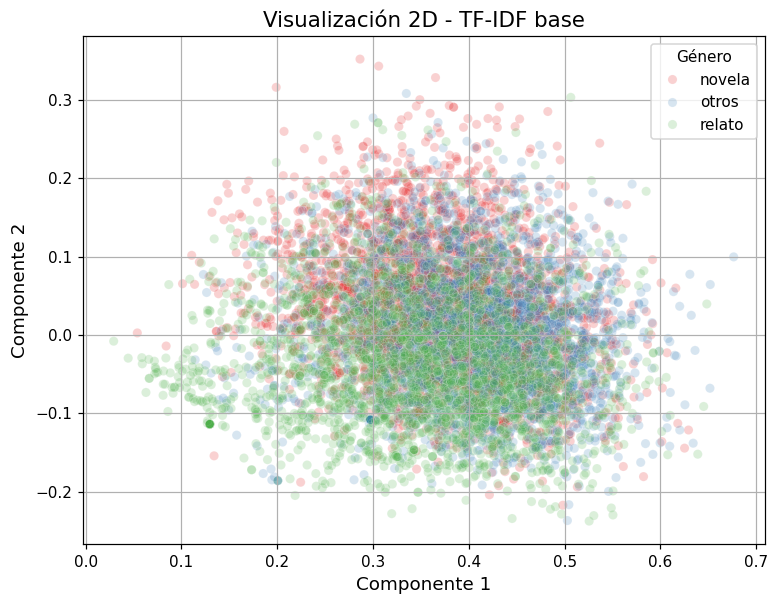

In [60]:
#1. Vectorizar con TF-IDF base
#2. Reducir a 2 dimensiones con TruncatedSVD(n_components=2)

tfidf_base = TfidfVectorizer(max_features=5000, min_df=2)
X_tfidf_base = tfidf_base.fit_transform(df_balanced['sinapsis_clean'])
y_tfidf_base = df_balanced['label'] 
svd_base = TruncatedSVD(n_components=2, random_state=42)
X_tfidf_base_2d = svd_base.fit_transform(X_tfidf_base)  
#3. Hacer un scatter plot coloreado por género para cada representación
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_tfidf_base_2d[:, 0], 
    y=X_tfidf_base_2d[:, 1], 
    hue=y_tfidf_base, 
    palette='Set1', 
    alpha=0.2
)
plt.title('Visualización 2D - TF-IDF base', fontsize=14)
plt.xlabel('Componente 1', fontsize=12)
plt.ylabel('Componente 2', fontsize=12)
plt.legend(title='Género')
plt.grid(True)
plt.show()


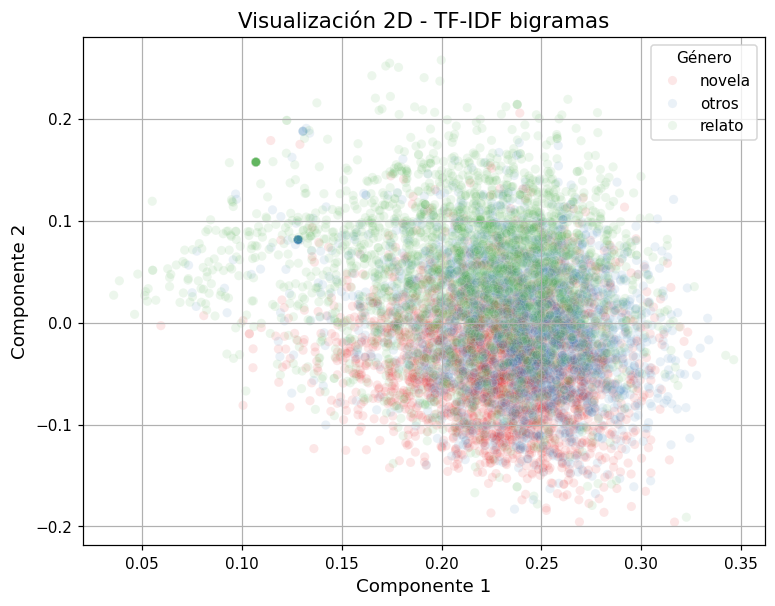

In [58]:
# Repetir visulización para TF-IDF bigramas
tfidf_bigrams = TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True, max_features=8000)
X_tfidf_bigrams = tfidf_bigrams.fit_transform(df_balanced['sinapsis_clean'])
y_tfidf_bigrams = df_balanced['label']
svd_bigrams = TruncatedSVD(n_components=2, random_state=42)
X_tfidf_bigrams_2d = svd_bigrams.fit_transform(X_tfidf_bigrams)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_tfidf_bigrams_2d[:, 0], 
    y=X_tfidf_bigrams_2d[:, 1], 
    hue=y_tfidf_bigrams, 
    palette='Set1', 
    alpha=0.1
)
plt.title('Visualización 2D - TF-IDF bigramas', fontsize=14)
plt.xlabel('Componente 1', fontsize=12)
plt.ylabel('Componente 2', fontsize=12)
plt.legend(title='Género')
plt.grid(True)
plt.show();